## Concussion vs. Control — Unified Stratified K-Fold Classification
One optimized model per family (LR, DT, RF, SVM, KNN, DNN), evaluated for accuracy,
precision, recall, F1, ROC and PR from a **single** cross-validation.

## Methodology & Reproducibility Notes

**One model per family (unified).** Each classifier's hyper-parameters are selected
**once** on the full dataset via `GridSearchCV` with a single objective (`roc_auc`);
that *same* fixed-hyper-parameter model is then evaluated with 10-fold cross-validation
to produce accuracy/precision/recall/F1, the ROC curve, and the PR curve. One model per
family across all three outputs (standard tune-then-cross-validate, not nested CV).

> Hyper-parameter selection uses the full dataset (mild optimism), then the chosen
> model is scored on held-out folds — the common applied-ML convention.

> **Note on the tuning objective.** `roc_auc` is used here (vs. the `accuracy` variant).
> Because the cohort is imbalanced (~68% controls), `roc_auc` emphasizes ranking of the
> positive (concussion) class rather than rewarding majority-class predictions, so it
> typically yields higher recall/F1 for the concussion class than `accuracy`-tuned models.
> Change `TUNE_SCORING` to explore other objectives.

**Reproducibility.** `StratifiedKFold(n_splits=10, shuffle=True, random_state=42)`
(outer) and `cv=5` / `cv=3` (inner) with `random_state=42`; `np.random.seed(42)`,
`tf.random.set_seed(42)`; RF/SVM seeded. All models use the same outer folds.

**Reporting.** ROC AUC is given as the AUC of the mean ROC curve and the mean ± SD
of per-fold AUCs. The PR figures show the **mean** PR curve across folds, with AP reported as the
mean ± SD of per-fold AP (matching the ROC convention). Precision/recall/F1
use `zero_division=0`. Interpolated TPRs are clipped to [0, 1].

In [40]:
# ===== Setup =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# --- Reproducibility / configuration (see config.md) ---
RANDOM_STATE = 42
N_SPLITS = 10        # outer evaluation folds (shared by every model)
INNER_SPLITS = 5     # inner GridSearchCV folds (3 for the DNN)
TUNE_SCORING = "roc_auc"   # single tuning objective for every model family
np.random.seed(RANDOM_STATE)

# --- Load and merge datasets ---
Yes_Concussion = pd.read_csv('S2P_Combined_WithHistory_20260111_TC.csv')
No_Concussion = pd.read_csv('S2P_Combined_NoHistory_20260111_TC.csv')
Yes_Concussion['data_type'] = 1   # Concussion
No_Concussion['data_type'] = 0    # No concussion
datas = pd.concat([Yes_Concussion, No_Concussion], ignore_index=True)

X_data = datas.iloc[:, :-1]
y = datas.iloc[:, -1].values
X = StandardScaler().fit(X_data).transform(X_data)
print("X shape:", X.shape, "| y shape:", y.shape)
print("Class distribution:", Counter(y.tolist()))

MODEL_ORDER = ['LR', 'DT', 'RF', 'SVM', 'KNN', 'DNN']
FULL_NAME = {'LR': 'Logistic Regression', 'DT': 'Decision Tree', 'RF': 'Random Forest',
             'SVM': 'Support Vector Machine', 'KNN': 'K-Nearest Neighbors',
             'DNN': 'Deep Neural Network'}
COLOR = {'LR': 'red', 'DT': 'green', 'RF': 'orange', 'SVM': 'cyan',
         'KNN': 'darkmagenta', 'DNN': 'blue'}
MR = {}   # results registry, filled by the per-model cells

X shape: (320, 91) | y shape: (320,)
Class distribution: Counter({0: 219, 1: 101})


In [41]:
# ===== Tune-once + K-fold evaluator (proper, non-nested CV) =====
# Hyper-parameters are selected ONCE on the full data via GridSearchCV(TUNE_SCORING);
# the SAME fixed-hyper-parameter model is then evaluated with N_SPLITS-fold CV to
# produce metrics, ROC and PR. One model per family across all three outputs.
def cv_evaluate(key, estimator, param_grid, *, inner_splits=INNER_SPLITS,
                n_jobs=-1, plot=True):
    name, color = FULL_NAME[key], COLOR[key]
    inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE)
    outer = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # 1) Select hyper-parameters once on the full dataset
    search = GridSearchCV(estimator, param_grid, scoring=TUNE_SCORING, cv=inner, n_jobs=n_jobs)
    search.fit(X, y)
    best_params = search.best_params_

    # 2) Evaluate the SAME tuned model with K-fold CV
    base_fpr = np.linspace(0, 1, 101)
    base_recall = np.linspace(0, 1, 101)
    acc, prec, rec, f1s, aucs, aps = [], [], [], [], [], []
    tprs, precs_interp, fold_roc, fold_pr = [], [], [], []
    y_real, y_proba = [], []

    for tr, te in outer.split(X, y):
        model = clone(estimator).set_params(**best_params)
        model.fit(X[tr], y[tr])
        y_pred = model.predict(X[te])
        proba = model.predict_proba(X[te])[:, 1]

        acc.append(accuracy_score(y[te], y_pred))
        prec.append(precision_score(y[te], y_pred, zero_division=0))
        rec.append(recall_score(y[te], y_pred, zero_division=0))
        f1s.append(f1_score(y[te], y_pred, zero_division=0))

        fpr, tpr, _ = roc_curve(y[te], proba); aucs.append(auc(fpr, tpr))
        ti = np.clip(np.interp(base_fpr, fpr, tpr), 0, 1); ti[0] = 0.0
        tprs.append(ti); fold_roc.append((fpr, tpr))

        pr_p, pr_r, _ = precision_recall_curve(y[te], proba)
        aps.append(average_precision_score(y[te], proba)); fold_pr.append((pr_r, pr_p))
        precs_interp.append(np.clip(np.interp(base_recall, pr_r[::-1], pr_p[::-1]), 0, 1))
        y_real.append(y[te]); y_proba.append(proba)

    tprs = np.array(tprs); mean_tpr = tprs.mean(0); std_tpr = tprs.std(0)
    mean_auc = auc(base_fpr, mean_tpr)
    y_real = np.concatenate(y_real); y_proba = np.concatenate(y_proba)
    precision, recall, _ = precision_recall_curve(y_real, y_proba)
    pooled_ap = average_precision_score(y_real, y_proba)
    precs_interp = np.array(precs_interp)

    R = dict(key=key, name=name, color=color,
             results={'test_accuracy': np.array(acc), 'test_precision': np.array(prec),
                      'test_recall': np.array(rec), 'test_f1': np.array(f1s)},
             aucs=np.array(aucs), aps=np.array(aps),
             base_fpr=base_fpr, mean_tpr=mean_tpr, std_tpr=std_tpr, mean_auc=mean_auc,
             precision=precision, recall=recall, y_real=y_real, y_proba=y_proba,
             pooled_ap=pooled_ap, base_recall=base_recall, precs_interp=precs_interp,
             best_params=best_params)

    print(f"\n=== {name} (tuned once on {TUNE_SCORING}; evaluated with {N_SPLITS}-fold CV) ===")
    print(f"  Best params: {best_params}")
    for m, lab in [('test_accuracy', 'Accuracy'), ('test_precision', 'Precision'),
                   ('test_recall', 'Recall'), ('test_f1', 'F1-Score')]:
        v = R['results'][m]; print(f"  {lab:9}: {v.mean():.3f} +/- {v.std():.3f}")
    print(f"  ROC AUC  : mean-curve {mean_auc:.3f} | fold {R['aucs'].mean():.3f} +/- {R['aucs'].std():.3f}")
    print(f"  PR  AP   : pooled {pooled_ap:.3f} | fold {R['aps'].mean():.3f} +/- {R['aps'].std():.3f}")

    if plot:
        # ROC
        plt.figure(figsize=(6, 6))
        for fpr, tpr in fold_roc:
            plt.plot(fpr, tpr, lw=1, alpha=0.3, color=color)
        upper = np.minimum(mean_tpr + std_tpr, 1); lower = np.maximum(mean_tpr - std_tpr, 0)
        plt.fill_between(base_fpr, lower, upper, color=color, alpha=0.2, label='±1 std. dev.')
        plt.plot(base_fpr, mean_tpr, color=color, lw=2,
                 label=r'Mean ROC (AUC = %0.3f $\pm$ %0.3f)' % (mean_auc, R['aucs'].std()))
        plt.plot([0, 1], [0, 1], 'k--', lw=1)
        plt.xlim([0, 1]); plt.ylim([0, 1]); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve'); plt.legend(loc='lower right')
        plt.gca().set_aspect('equal', adjustable='box'); plt.tight_layout(); plt.show()
        # PR (mean across folds, mirroring the ROC panel)
        plt.figure(figsize=(6, 6))
        for pr_r, pr_p in fold_pr:
            plt.plot(pr_r, pr_p, lw=1, alpha=0.3, color=color)
        mean_prec = precs_interp.mean(0); std_prec = precs_interp.std(0)
        pu = np.minimum(mean_prec + std_prec, 1); pl = np.maximum(mean_prec - std_prec, 0)
        plt.fill_between(base_recall, pl, pu, color=color, alpha=0.2, label='±1 std. dev.')
        plt.plot(base_recall, mean_prec, color=color, lw=2,
                 label=r'Mean PR (AP = %0.3f $\pm$ %0.3f)' % (R['aps'].mean(), R['aps'].std()))
        plt.xlim([0, 1]); plt.ylim([0, 1]); plt.xlabel('Recall'); plt.ylabel('Precision')
        plt.title(f'{name} PR Curve'); plt.legend(loc='lower right')
        plt.gca().set_aspect('equal', adjustable='box'); plt.tight_layout(); plt.show()
    return R

In [42]:
# ===== Parameter grids (single objective: TUNE_SCORING) =====
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

GRIDS = {
    'LR': (LogisticRegression(max_iter=1000),
           {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}),
    'DT': (DecisionTreeClassifier(random_state=RANDOM_STATE),
           {'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, 5, 6, 7, None],
            'min_samples_split': [2, 4, 6], 'min_samples_leaf': [1, 2, 3],
            'class_weight': [None, 'balanced']}),
    'RF': (RandomForestClassifier(random_state=RANDOM_STATE),
           {'n_estimators': [100, 200, 300], 'max_features': ['sqrt', 'log2'],
            'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}),
    'SVM': (SVC(probability=True, random_state=RANDOM_STATE),
            {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.1], 'kernel': ['linear', 'rbf']}),
    'KNN': (KNeighborsClassifier(),
            {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'p': [1, 2]}),
}

## Per-model evaluation (LR, DT, RF, SVM, KNN)


=== Logistic Regression (tuned once on roc_auc; evaluated with 10-fold CV) ===
  Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Accuracy : 0.625 +/- 0.067
  Precision: 0.389 +/- 0.129
  Recall   : 0.336 +/- 0.119
  F1-Score : 0.359 +/- 0.122
  ROC AUC  : mean-curve 0.567 | fold 0.567 +/- 0.096
  PR  AP   : pooled 0.388 | fold 0.439 +/- 0.097


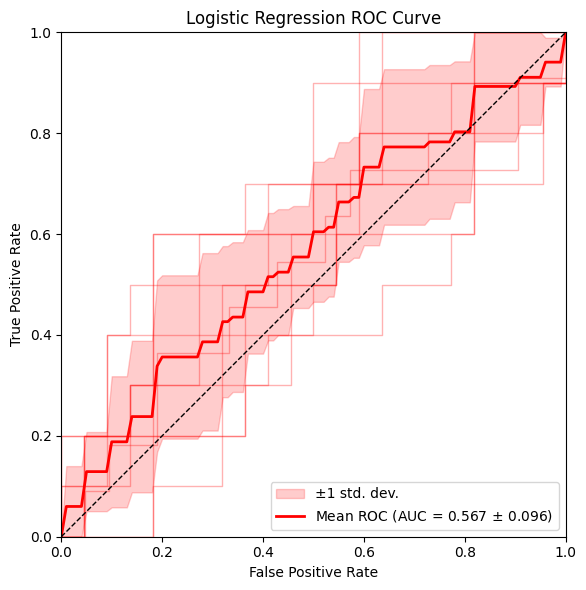

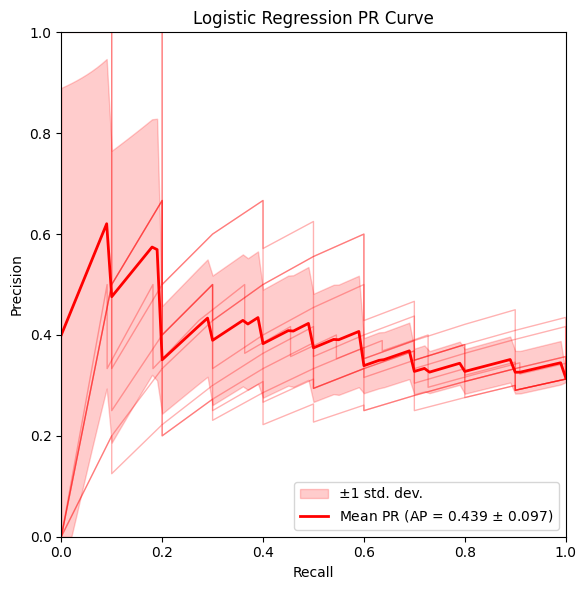

In [43]:
est, grid = GRIDS['LR']
MR['LR'] = cv_evaluate('LR', est, grid)


=== Decision Tree (tuned once on roc_auc; evaluated with 10-fold CV) ===
  Best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 4}
  Accuracy : 0.634 +/- 0.067
  Precision: 0.351 +/- 0.176
  Recall   : 0.219 +/- 0.161
  F1-Score : 0.261 +/- 0.157
  ROC AUC  : mean-curve 0.522 | fold 0.522 +/- 0.112
  PR  AP   : pooled 0.340 | fold 0.380 +/- 0.107


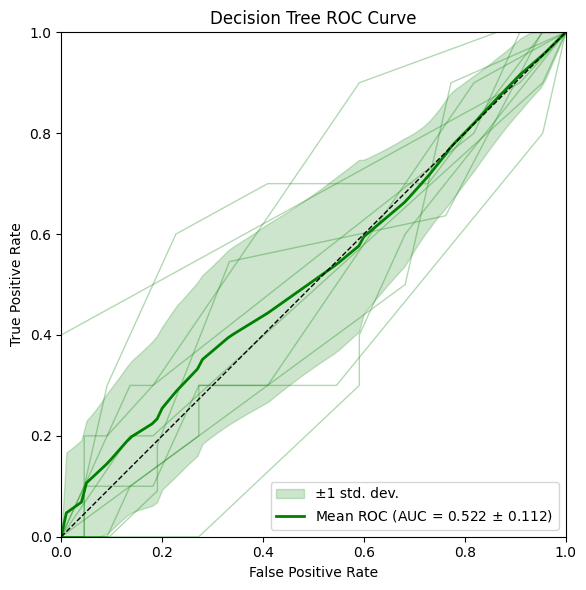

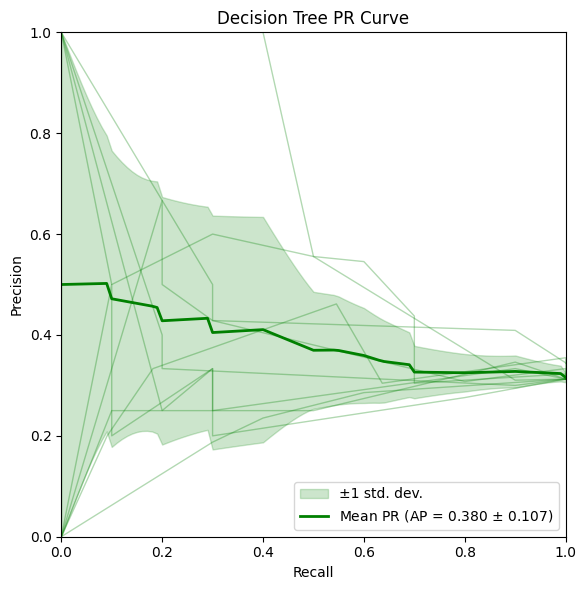

In [44]:
est, grid = GRIDS['DT']
MR['DT'] = cv_evaluate('DT', est, grid)


=== Random Forest (tuned once on roc_auc; evaluated with 10-fold CV) ===
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  Accuracy : 0.675 +/- 0.025
  Precision: 0.283 +/- 0.325
  Recall   : 0.078 +/- 0.085
  F1-Score : 0.118 +/- 0.125
  ROC AUC  : mean-curve 0.509 | fold 0.509 +/- 0.089
  PR  AP   : pooled 0.334 | fold 0.376 +/- 0.080


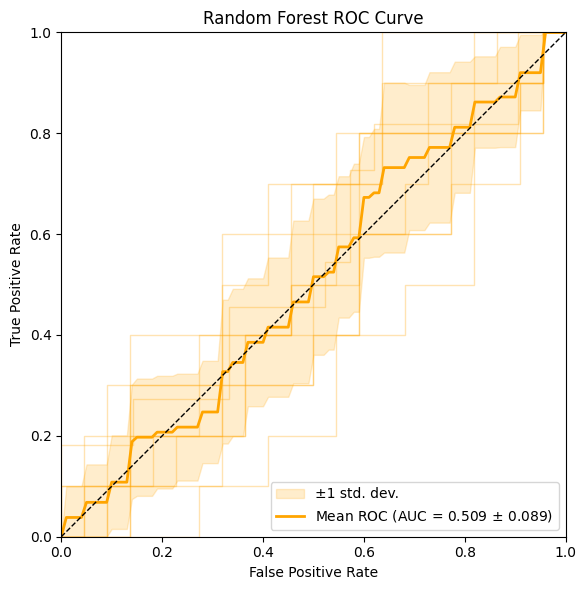

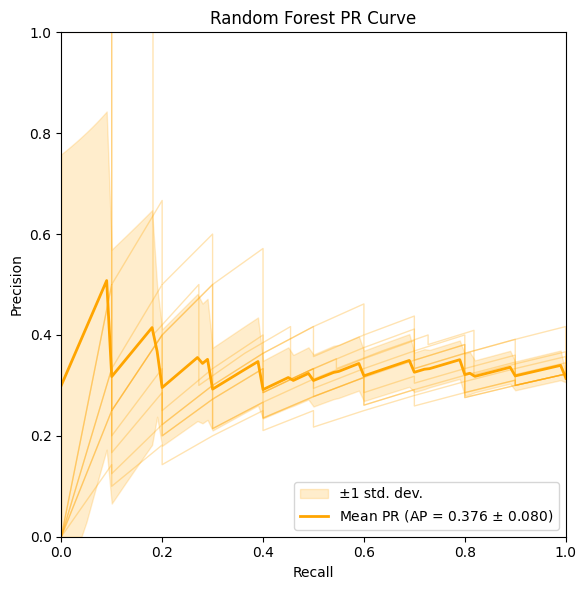

In [45]:
est, grid = GRIDS['RF']
MR['RF'] = cv_evaluate('RF', est, grid)


=== Support Vector Machine (tuned once on roc_auc; evaluated with 10-fold CV) ===
  Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy : 0.606 +/- 0.060
  Precision: 0.378 +/- 0.086
  Recall   : 0.367 +/- 0.103
  F1-Score : 0.368 +/- 0.087
  ROC AUC  : mean-curve 0.575 | fold 0.575 +/- 0.094
  PR  AP   : pooled 0.351 | fold 0.482 +/- 0.108


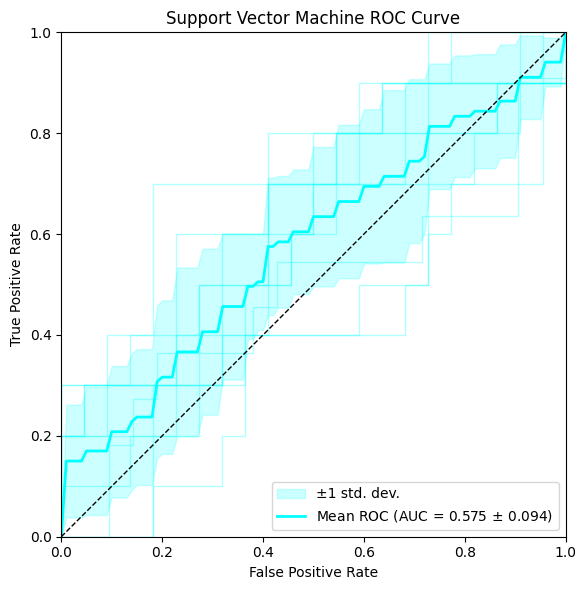

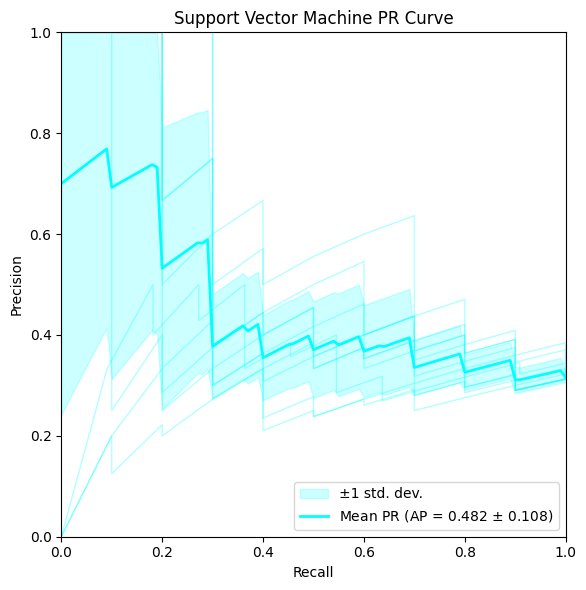

In [46]:
est, grid = GRIDS['SVM']
MR['SVM'] = cv_evaluate('SVM', est, grid)


=== K-Nearest Neighbors (tuned once on roc_auc; evaluated with 10-fold CV) ===
  Best params: {'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}
  Accuracy : 0.684 +/- 0.043
  Precision: 0.417 +/- 0.352
  Recall   : 0.099 +/- 0.089
  F1-Score : 0.156 +/- 0.136
  ROC AUC  : mean-curve 0.515 | fold 0.515 +/- 0.088
  PR  AP   : pooled 0.338 | fold 0.371 +/- 0.071


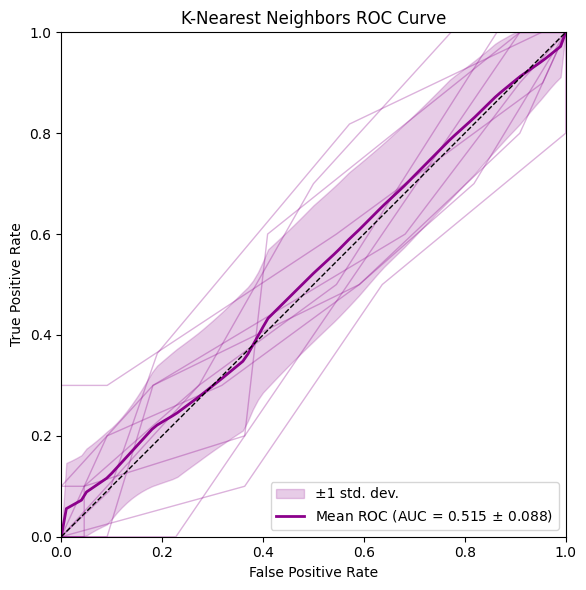

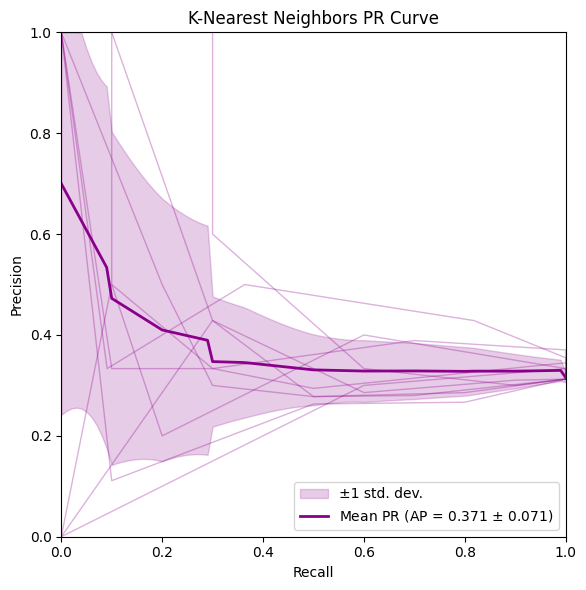

In [47]:
est, grid = GRIDS['KNN']
MR['KNN'] = cv_evaluate('KNN', est, grid)

## Deep Neural Network (tuned once, then 10-fold CV)


=== Deep Neural Network (tuned once on roc_auc; evaluated with 10-fold CV) ===
  Best params: {'batch_size': 32, 'epochs': 50, 'model__optimizer': 'rmsprop', 'model__units1': 12, 'model__units2': 8}
  Accuracy : 0.622 +/- 0.090
  Precision: 0.391 +/- 0.137
  Recall   : 0.249 +/- 0.104
  F1-Score : 0.291 +/- 0.106
  ROC AUC  : mean-curve 0.514 | fold 0.514 +/- 0.105
  PR  AP   : pooled 0.341 | fold 0.393 +/- 0.081


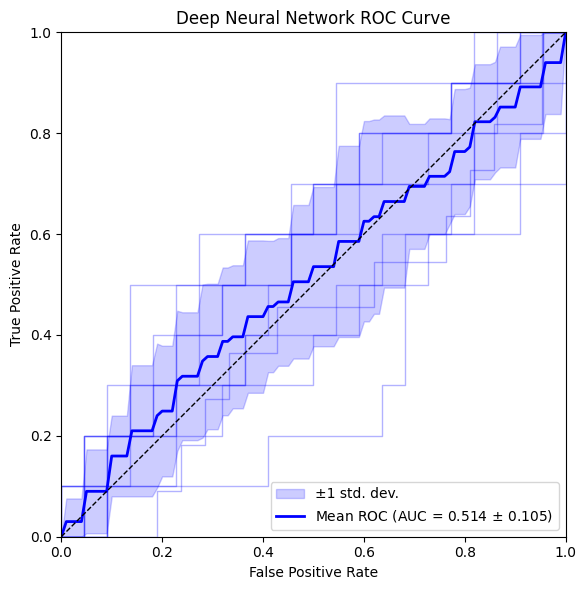

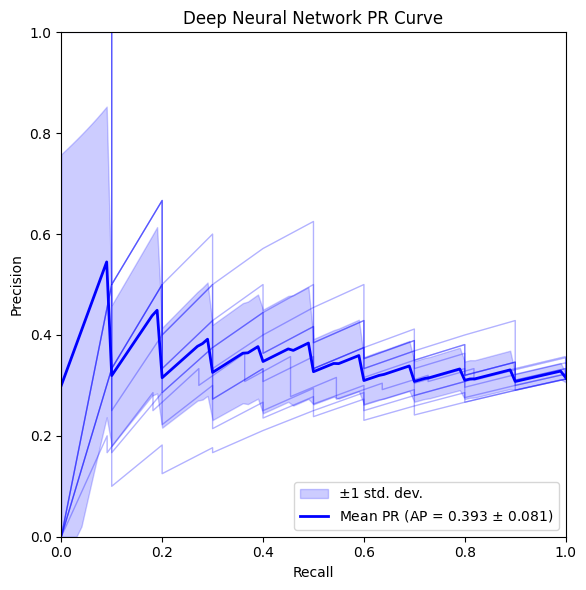

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

def create_dnn(units1=12, units2=8, optimizer='adam'):
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential([
        Input(shape=(X.shape[1],)),
        Dense(units1, activation='relu'),
        Dense(units2, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

dnn = KerasClassifier(model=create_dnn, verbose=0,
                      callbacks=[EarlyStopping(monitor='loss', patience=5)])
dnn_grid = {
    'model__units1': [8, 12], 'model__units2': [6, 8],
    'model__optimizer': ['adam', 'rmsprop'], 'batch_size': [32], 'epochs': [50],
}
# n_jobs=1 and 3 inner folds keep the Keras grid tractable
MR['DNN'] = cv_evaluate('DNN', dnn, dnn_grid, inner_splits=3, n_jobs=1)

## Combined metrics (mean ± SD across the 10 outer folds)

In [49]:
# Use only the models actually evaluated (works whether or not the DNN cell ran)
PRESENT = [k for k in MODEL_ORDER if k in MR]

for metric, label in [('test_accuracy', 'Accuracy'), ('test_precision', 'Precision'),
                      ('test_recall', 'Recall'), ('test_f1', 'F1-Score')]:
    print(f"\n{label} (Mean +/- SD):")
    for k in PRESENT:
        v = MR[k]['results'][metric]
        print(f"  {FULL_NAME[k]:24}: {v.mean():.4f} ({v.std():.4f})")


Accuracy (Mean +/- SD):
  Logistic Regression     : 0.6250 (0.0670)
  Decision Tree           : 0.6344 (0.0671)
  Random Forest           : 0.6750 (0.0250)
  Support Vector Machine  : 0.6062 (0.0596)
  K-Nearest Neighbors     : 0.6844 (0.0430)
  Deep Neural Network     : 0.6219 (0.0900)

Precision (Mean +/- SD):
  Logistic Regression     : 0.3888 (0.1291)
  Decision Tree           : 0.3512 (0.1764)
  Random Forest           : 0.2833 (0.3253)
  Support Vector Machine  : 0.3777 (0.0856)
  K-Nearest Neighbors     : 0.4167 (0.3516)
  Deep Neural Network     : 0.3909 (0.1372)

Recall (Mean +/- SD):
  Logistic Regression     : 0.3364 (0.1187)
  Decision Tree           : 0.2191 (0.1607)
  Random Forest           : 0.0782 (0.0848)
  Support Vector Machine  : 0.3673 (0.1027)
  K-Nearest Neighbors     : 0.0991 (0.0895)
  Deep Neural Network     : 0.2491 (0.1038)

F1-Score (Mean +/- SD):
  Logistic Regression     : 0.3590 (0.1219)
  Decision Tree           : 0.2609 (0.1571)
  Random Forest      

## Performance Metrics Visualization

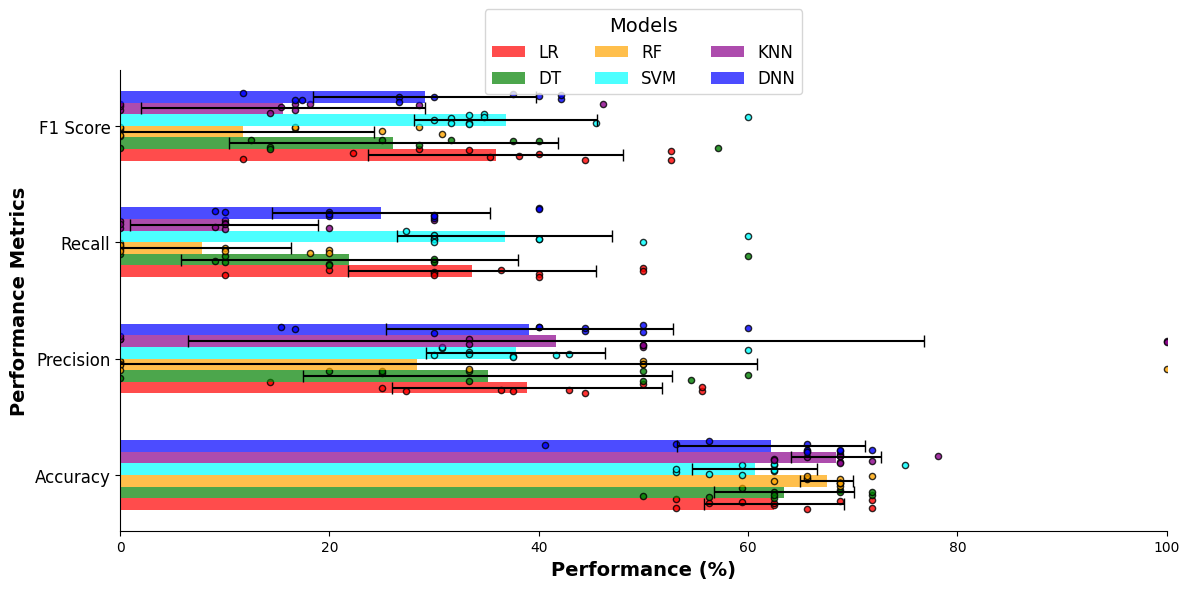

In [50]:
metric_keys = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
PRESENT = [k for k in MODEL_ORDER if k in MR]
n_metrics, n_models = len(metric_keys), len(PRESENT)

means = np.array([[MR[k]['results'][m].mean() * 100 for k in PRESENT] for m in metric_keys])
stds  = np.array([[MR[k]['results'][m].std()  * 100 for k in PRESENT] for m in metric_keys])

y_pos = np.arange(n_metrics); width = 0.1
fig, ax = plt.subplots(figsize=(12, 6))
np.random.seed(RANDOM_STATE); jitter = 0.05
for i, k in enumerate(PRESENT):
    offset = (i - n_models / 2) * width + width / 2
    ax.barh(y_pos + offset, means[:, i], height=width, xerr=stds[:, i], capsize=4,
            label=k, color=COLOR[k], alpha=0.7,
            error_kw={'elinewidth': 1.5, 'color': COLOR[k]})
    for j, m in enumerate(metric_keys):
        fold_vals = MR[k]['results'][m] * 100
        yj = y_pos[j] + offset + np.random.uniform(-jitter, jitter, size=len(fold_vals))
        ax.scatter(fold_vals, yj, facecolor=COLOR[k], edgecolor='black', s=20, alpha=0.8, linewidth=1)
ax.set_xlabel('Performance (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Performance Metrics', fontsize=14, fontweight='bold')
ax.set_yticks(y_pos); ax.set_yticklabels(metric_names, fontsize=12); ax.set_xlim(0, 100)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, title='Models',
          fontsize=12, title_fontsize=14)
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
plt.tight_layout()
fig.savefig("Combined Performance Metrics Curve 12062026_rocauc.png",
            dpi=1200, bbox_inches='tight')
plt.show()

## Combined ROC Curve

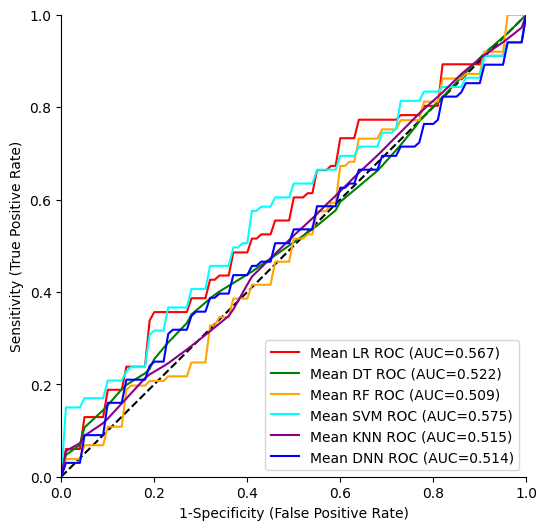

Average AUC across models: 0.5336368147801546


In [51]:
PRESENT = [k for k in MODEL_ORDER if k in MR]
fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(1, 1, 1)
plt.xlim(0, 1); plt.ylim(0, 1); plt.plot([0, 1], [0, 1], 'k--')
for k in PRESENT:
    plt.plot(MR[k]['base_fpr'], MR[k]['mean_tpr'], color=COLOR[k],
             label=r'Mean %s ROC (AUC=%.3f)' % (k, MR[k]['mean_auc']))
plt.xlabel('1-Specificity (False Positive Rate)'); plt.ylabel('Sensitivity (True Positive Rate)')
plt.legend(loc="lower right")
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
fig.savefig("Combined StratifiedKFold K-fold ROC Curve 12062026_rocauc.png", dpi=1200)
plt.show()

avg_auc = np.mean([MR[k]['mean_auc'] for k in PRESENT])
print("Average AUC across models:", avg_auc)

## Combined PR Curve

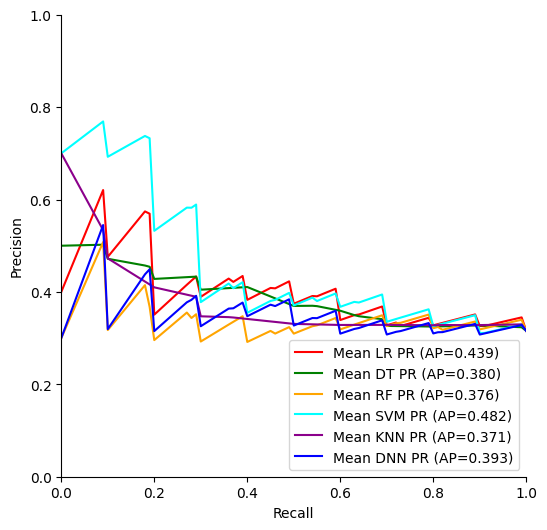

In [52]:
PRESENT = [k for k in MODEL_ORDER if k in MR]
fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(1, 1, 1)
plt.xlim(0, 1); plt.ylim(0, 1)
for k in PRESENT:
    mean_prec = MR[k]['precs_interp'].mean(0)
    plt.plot(MR[k]['base_recall'], mean_prec, color=COLOR[k],
             label=r'Mean %s PR (AP=%.3f)' % (k, MR[k]['aps'].mean()))
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend(loc="lower right")
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
fig.savefig("Combined StratifiedKFold K-fold PR Curve 12062026_rocauc.png", dpi=1200)
plt.show()